In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import mean_absolute_error

plt.style.use("default")

In [2]:
perovskite_dataset = pd.read_json('../data/perovskite_dataset.json')

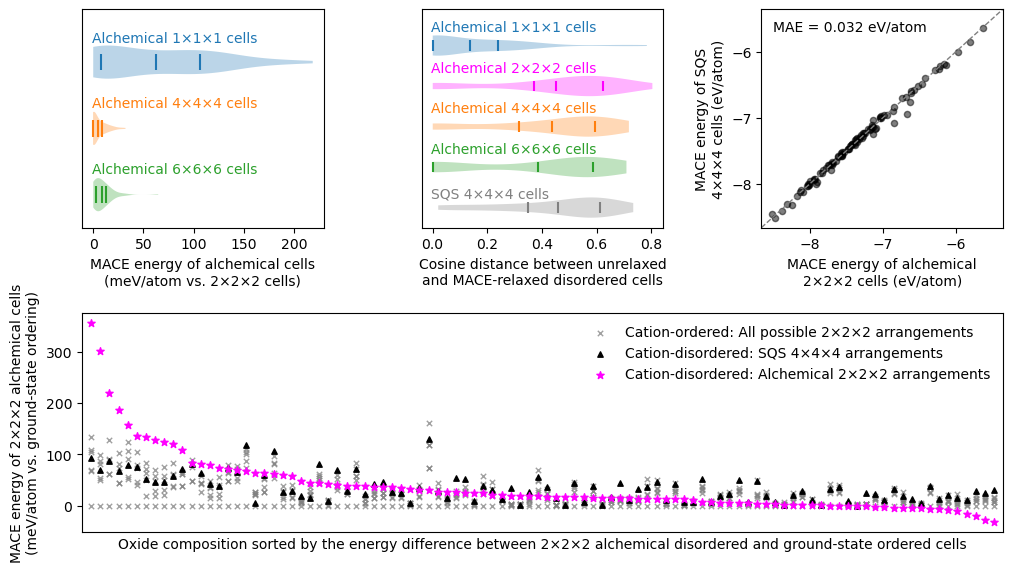

In [4]:
fig, axs = plt.subplot_mosaic(
    """
    ABC
    DDD
    """
, figsize=(10, 5.5), constrained_layout=True, gridspec_kw={'hspace': 0.1, 'wspace': 0.05})

axs['A'].set_xlabel('MACE energy of alchemical cells\n(meV/atom vs. 2×2×2 cells)')
colors = ['C0', 'C1', 'C2']
for index, cell_type in enumerate(['111', '444', '666']):
    temp_raw_data = (perovskite_dataset['alchemical_MACE_relaxed_' + cell_type + '_energy_per_atom'] - perovskite_dataset['alchemical_MACE_relaxed_222_energy_per_atom'])*1000
    temp_vp = axs['A'].violinplot(
        temp_raw_data[~pd.isnull(temp_raw_data)], positions=[3-index], widths=0.5, vert=False, 
        showmeans=True, showextrema=False, showmedians=False, points=100, bw_method=0.5, quantiles=[0.25, 0.75],
    )
    for pc in temp_vp['bodies']:
        pc.set_facecolor(colors[index])
    temp_vp['cquantiles'].set_color(colors[index])   
    temp_vp['cmeans'].set_color(colors[index])  
axs['A'].set_ylim(0.5, 3.8)
axs['A'].set_yticks([])
axs['A'].text(0.04, 0.90, 'Alchemical 1×1×1 cells', horizontalalignment='left', verticalalignment='top', transform=axs['A'].transAxes, color='C0')
axs['A'].text(0.04, 0.60, 'Alchemical 4×4×4 cells', horizontalalignment='left', verticalalignment='top', transform=axs['A'].transAxes, color='C1')
axs['A'].text(0.04, 0.30, 'Alchemical 6×6×6 cells', horizontalalignment='left', verticalalignment='top', transform=axs['A'].transAxes, color='C2')

axs['B'].set_xlabel('Cosine distance between unrelaxed\nand MACE-relaxed disordered cells')
colors = ['C0', 'magenta', 'C1', 'C2', 'grey']
for index, cell_type in enumerate(['111', '222', '444', '666', 'sqs']):
    if cell_type == 'sqs':
        temp_raw_data = perovskite_dataset['SQS_MACE_444_struct_diff']        
    else: 
        temp_raw_data = perovskite_dataset['alchemical_MACE_' + cell_type + '_struct_diff']
    temp_vp = axs['B'].violinplot(
        temp_raw_data[~pd.isnull(temp_raw_data)], positions=[5-index], widths=0.5, vert=False, 
        showmeans=True, showextrema=False, showmedians=False, points=100, bw_method=0.5, quantiles=[0.25, 0.75],
    )
    for pc in temp_vp['bodies']:
        pc.set_facecolor(colors[index])
    temp_vp['cquantiles'].set_color(colors[index])   
    temp_vp['cmeans'].set_color(colors[index])     
axs['B'].set_ylim(0.5, 5.9)
axs['B'].set_yticks([])
axs['B'].text(0.04, 0.95, 'Alchemical 1×1×1 cells', horizontalalignment='left', verticalalignment='top', transform=axs['B'].transAxes, color='C0')
axs['B'].text(0.04, 0.76, 'Alchemical 2×2×2 cells', horizontalalignment='left', verticalalignment='top', transform=axs['B'].transAxes, color='magenta')
axs['B'].text(0.04, 0.58, 'Alchemical 4×4×4 cells', horizontalalignment='left', verticalalignment='top', transform=axs['B'].transAxes, color='C1')
axs['B'].text(0.04, 0.39, 'Alchemical 6×6×6 cells', horizontalalignment='left', verticalalignment='top', transform=axs['B'].transAxes, color='C2')
axs['B'].text(0.04, 0.19, 'SQS 4×4×4 cells', horizontalalignment='left', verticalalignment='top', transform=axs['B'].transAxes, color='grey')

ordered_energy_diffs = (np.array(perovskite_dataset['ordered_MACE_relaxed_222_energies_per_atom'].to_list()) - np.array(perovskite_dataset['ordered_MACE_relaxed_222_energies_per_atom'].to_list()).min(axis=1, keepdims=True))*1000
alchemical_energy_diffs = (np.array(perovskite_dataset['alchemical_MACE_relaxed_222_energy_per_atom']) - np.array(perovskite_dataset['ordered_MACE_relaxed_222_energies_per_atom'].to_list()).min(axis=1))*1000
SQS_energy_diffs = (np.array(perovskite_dataset['SQS_MACE_relaxed_444_energy_per_atom']) - np.array(perovskite_dataset['ordered_MACE_relaxed_222_energies_per_atom'].to_list()).min(axis=1))*1000

axs['C'].set_xlabel('MACE energy of alchemical\n2×2×2 cells (eV/atom)')
axs['C'].set_ylabel('MACE energy of SQS\n4×4×4 cells (eV/atom)')
axs['C'].set_yticks([-8, -7, -6])
axs['C'].axline((-8.5, -8.5), (-5.5, -5.5), color='grey', linestyle='--', linewidth=1)
axs['C'].scatter(perovskite_dataset['alchemical_MACE_relaxed_222_energy_per_atom'], perovskite_dataset['SQS_MACE_relaxed_444_energy_per_atom'], s=20, color='black', alpha=0.5)
axs['C'].text(0.05, 0.95, 'MAE = {:.3f} eV/atom'.format(mean_absolute_error(perovskite_dataset['alchemical_MACE_relaxed_222_energy_per_atom'], perovskite_dataset['SQS_MACE_relaxed_444_energy_per_atom'])), transform=axs['C'].transAxes, ha='left', va='top')

axs['D'].set_xlabel('Oxide composition sorted by the energy difference between 2×2×2 alchemical disordered and ground-state ordered cells') 
axs['D'].set_ylabel('MACE energy of 2×2×2 alchemical cells\n(meV/atom vs. ground-state ordering)')
axs['D'].set_xlim(-1, len(alchemical_energy_diffs))
axs['D'].set_xticks([])
sorted_index_alchemical_energy_diffs = np.argsort(alchemical_energy_diffs)
axs['D'].scatter(
    np.repeat(len(sorted_index_alchemical_energy_diffs) - 1 - np.arange(len(sorted_index_alchemical_energy_diffs)), 6), 
    ordered_energy_diffs[sorted_index_alchemical_energy_diffs].flatten(),
    marker='x', color='grey', alpha=0.75, linewidths=1, s=15, label='Cation-ordered: All possible 2×2×2 arrangements',
)
axs['D'].scatter(
    len(sorted_index_alchemical_energy_diffs) - 1 - np.arange(len(sorted_index_alchemical_energy_diffs)), 
    SQS_energy_diffs[sorted_index_alchemical_energy_diffs],
    marker='^', color='black', alpha=1, linewidths=1, s=15, label='Cation-disordered: SQS 4×4×4 arrangements',
)
axs['D'].scatter(
    len(sorted_index_alchemical_energy_diffs) - 1 - np.arange(len(sorted_index_alchemical_energy_diffs)), 
    alchemical_energy_diffs[sorted_index_alchemical_energy_diffs],
    marker='*', color='magenta', alpha=1, linewidths=1, s=30, label='Cation-disordered: Alchemical 2×2×2 arrangements',
)
axs['D'].legend(frameon=False);
plt.savefig('tempC.pdf')